# 02 - Análisis Exploratorio de Datos (EDA)
Visualizaciones y análisis de distribuciones, correlaciones y relaciones con el target.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings                        # ← mover acá arriba
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/smoking_labeled.csv')

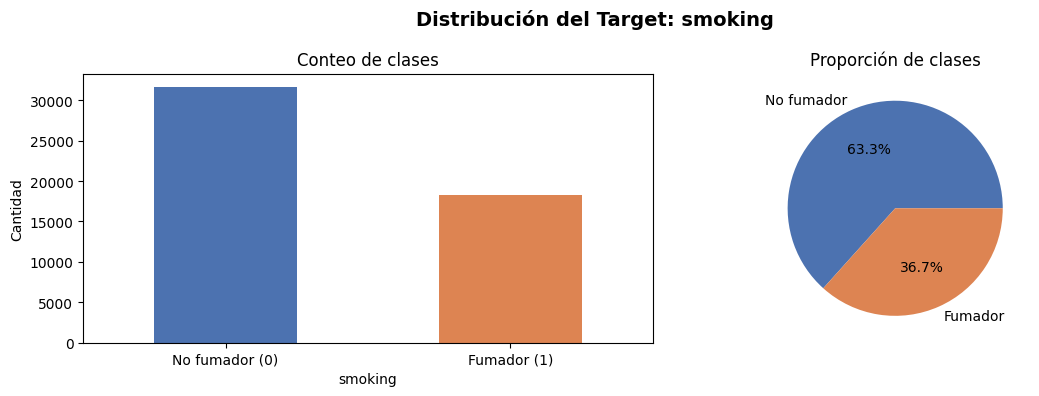

In [4]:

# ── Distribución del target ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['smoking'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Conteo de clases')
axes[0].set_xticklabels(['No fumador (0)', 'Fumador (1)'], rotation=0)
axes[0].set_ylabel('Cantidad')

df['smoking'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['No fumador', 'Fumador'], colors=['#4C72B0','#DD8452'])
axes[1].set_title('Proporción de clases')
axes[1].set_ylabel('')

plt.suptitle('Distribución del Target: smoking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


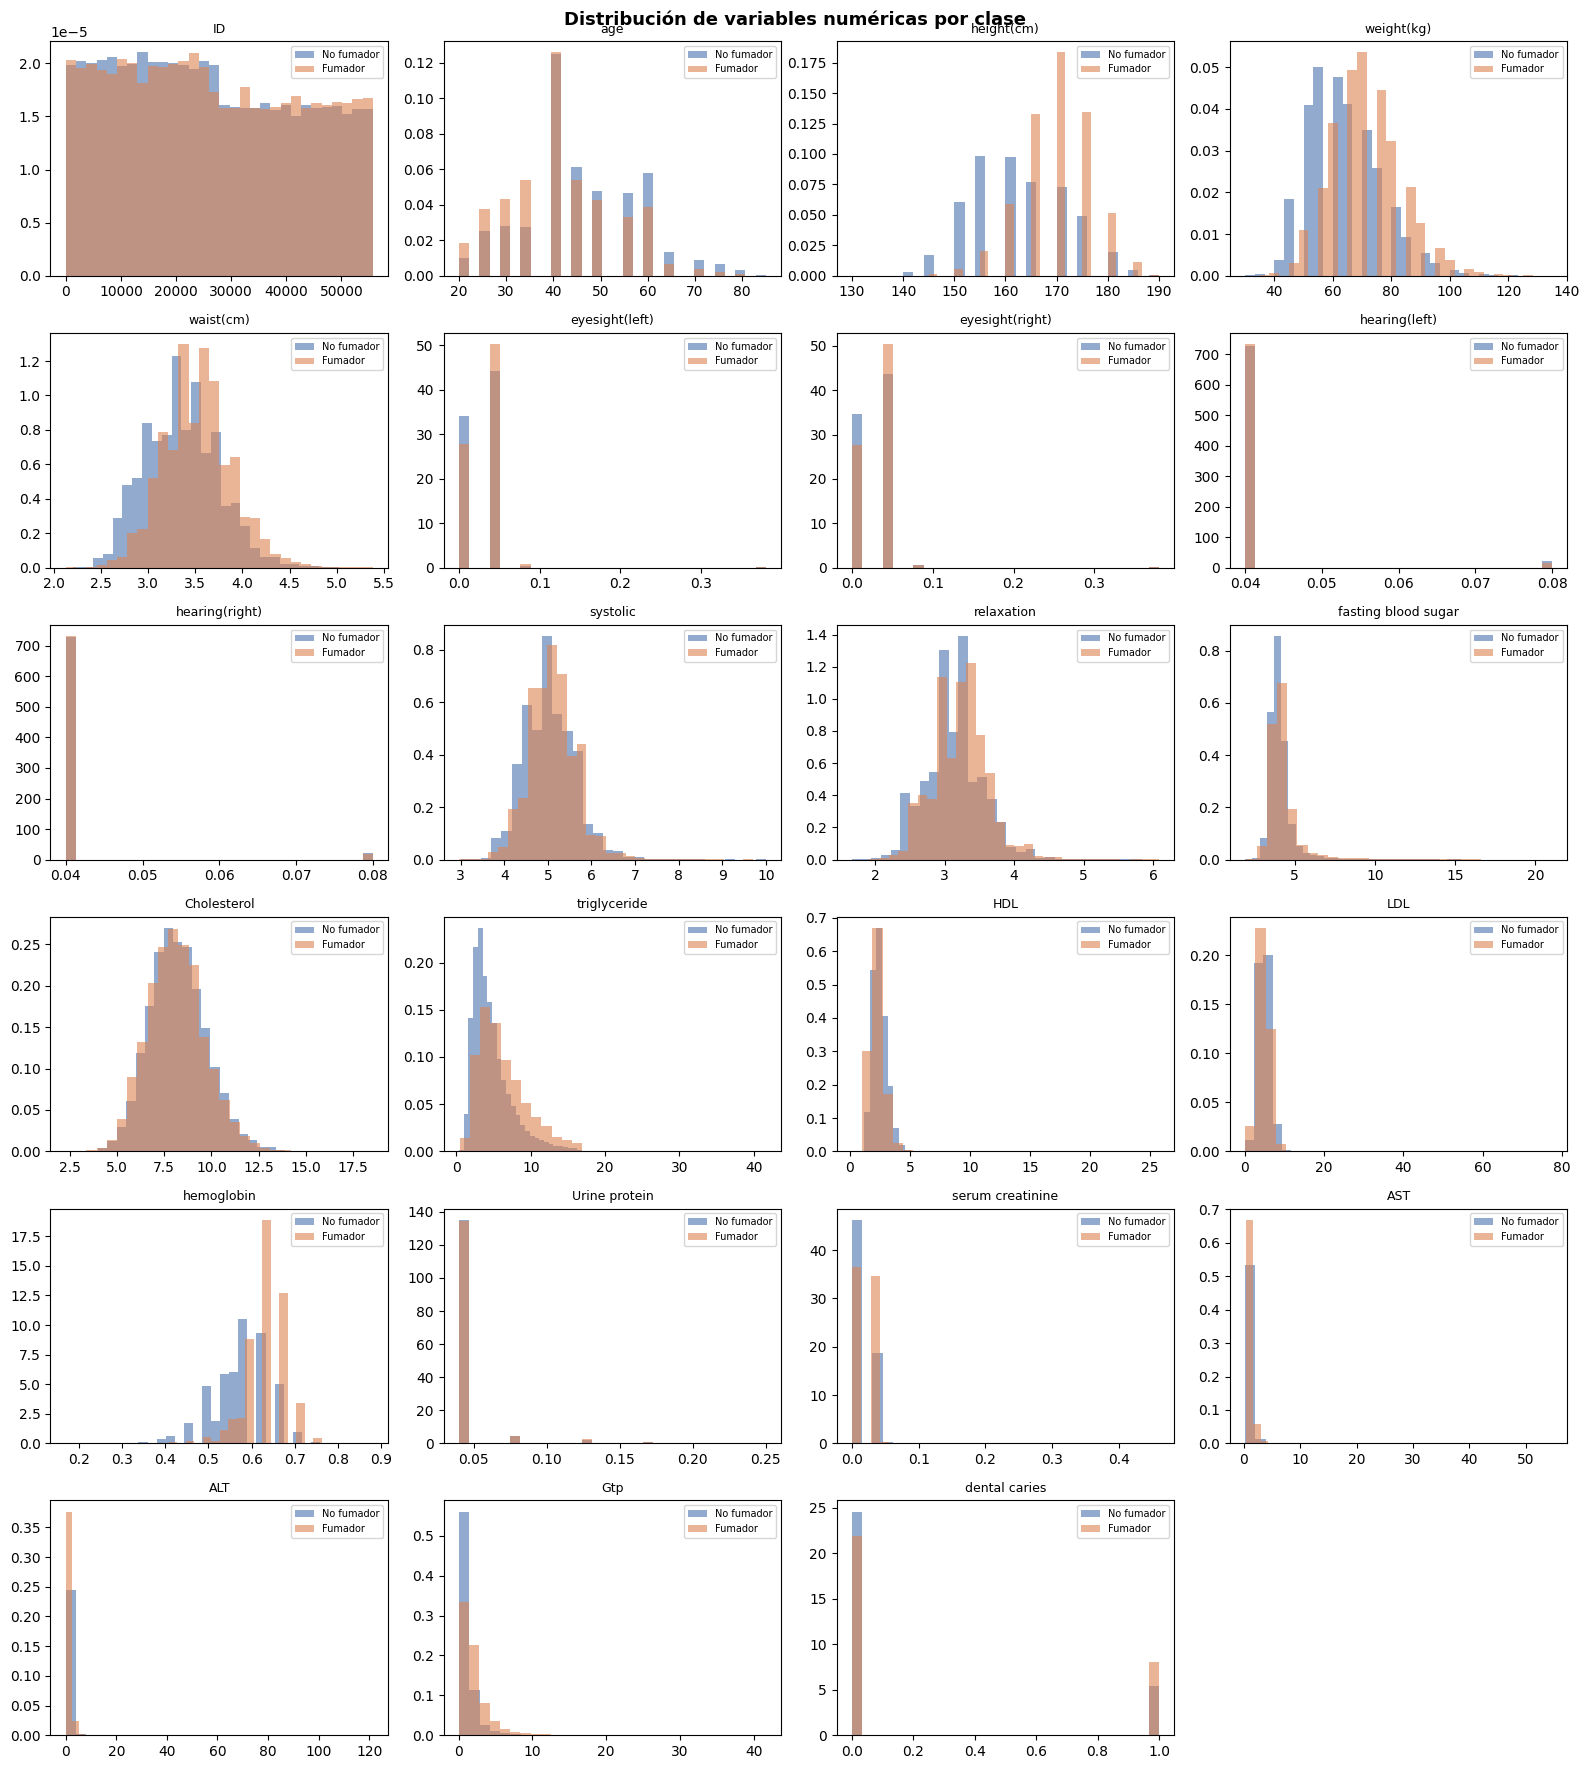

In [5]:

# ── Variables numéricas: distribución por clase ────────────────────────────
num_cols = df.select_dtypes(include='number').columns.drop('smoking', errors='ignore').tolist()
n = len(num_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for val, label, color in [(0, 'No fumador', '#4C72B0'), (1, 'Fumador', '#DD8452')]:
        subset = df[df['smoking'] == val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


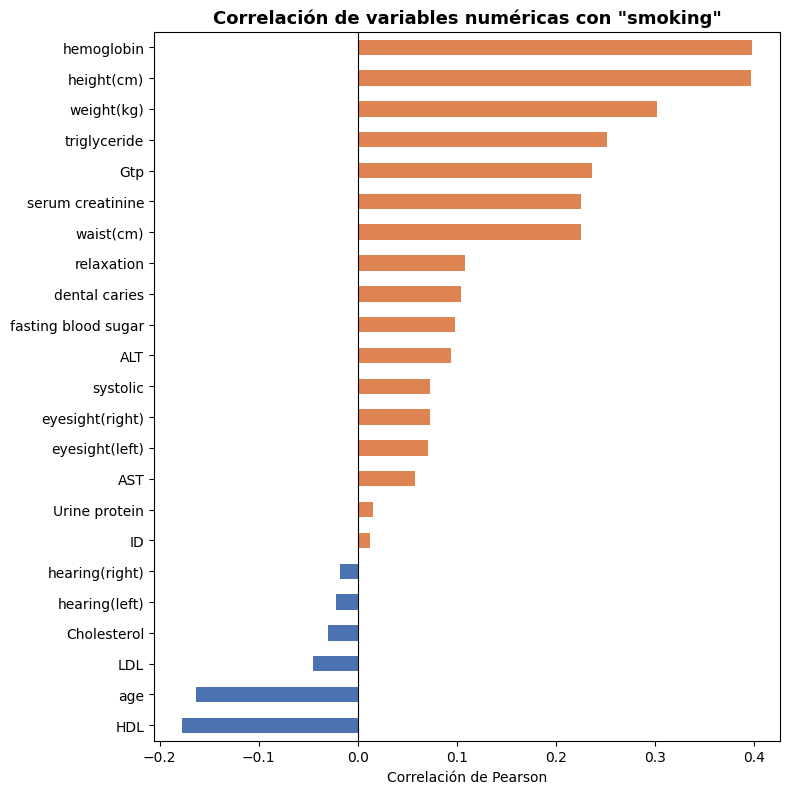

In [6]:

# ── Correlación con el target ──────────────────────────────────────────────
correlations = df[num_cols + ['smoking']].corr()['smoking'].drop('smoking').sort_values()

fig, ax = plt.subplots(figsize=(8, max(5, len(correlations)*0.35)))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables numéricas con "smoking"', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


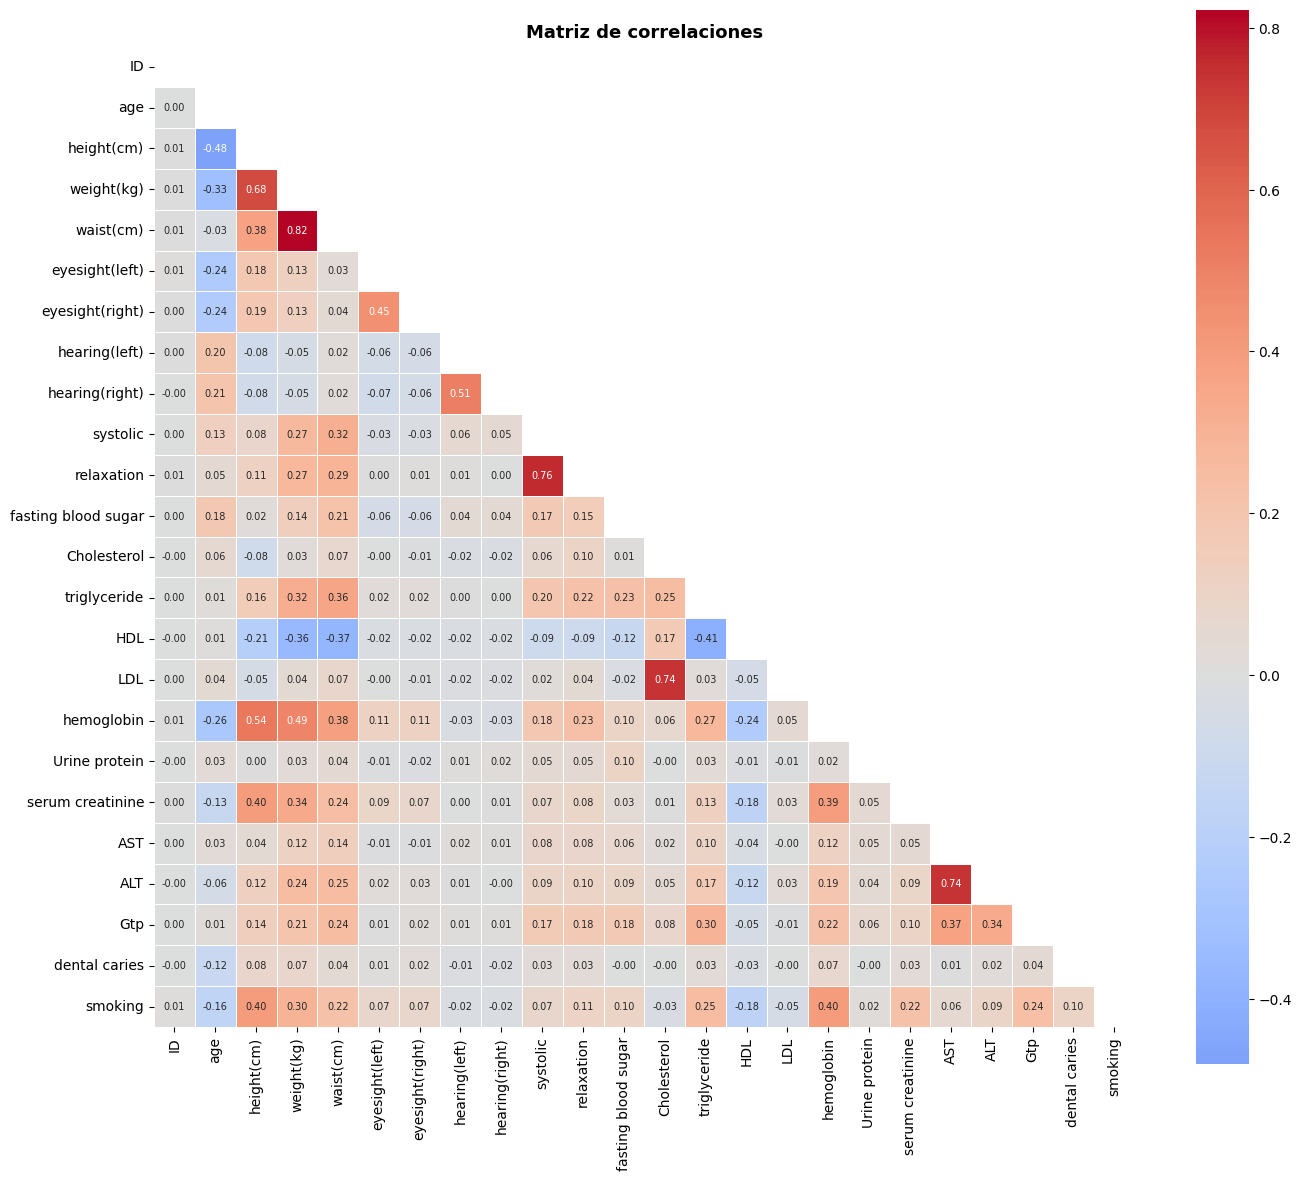

In [7]:

# ── Heatmap de correlaciones ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[num_cols + ['smoking']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de correlaciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


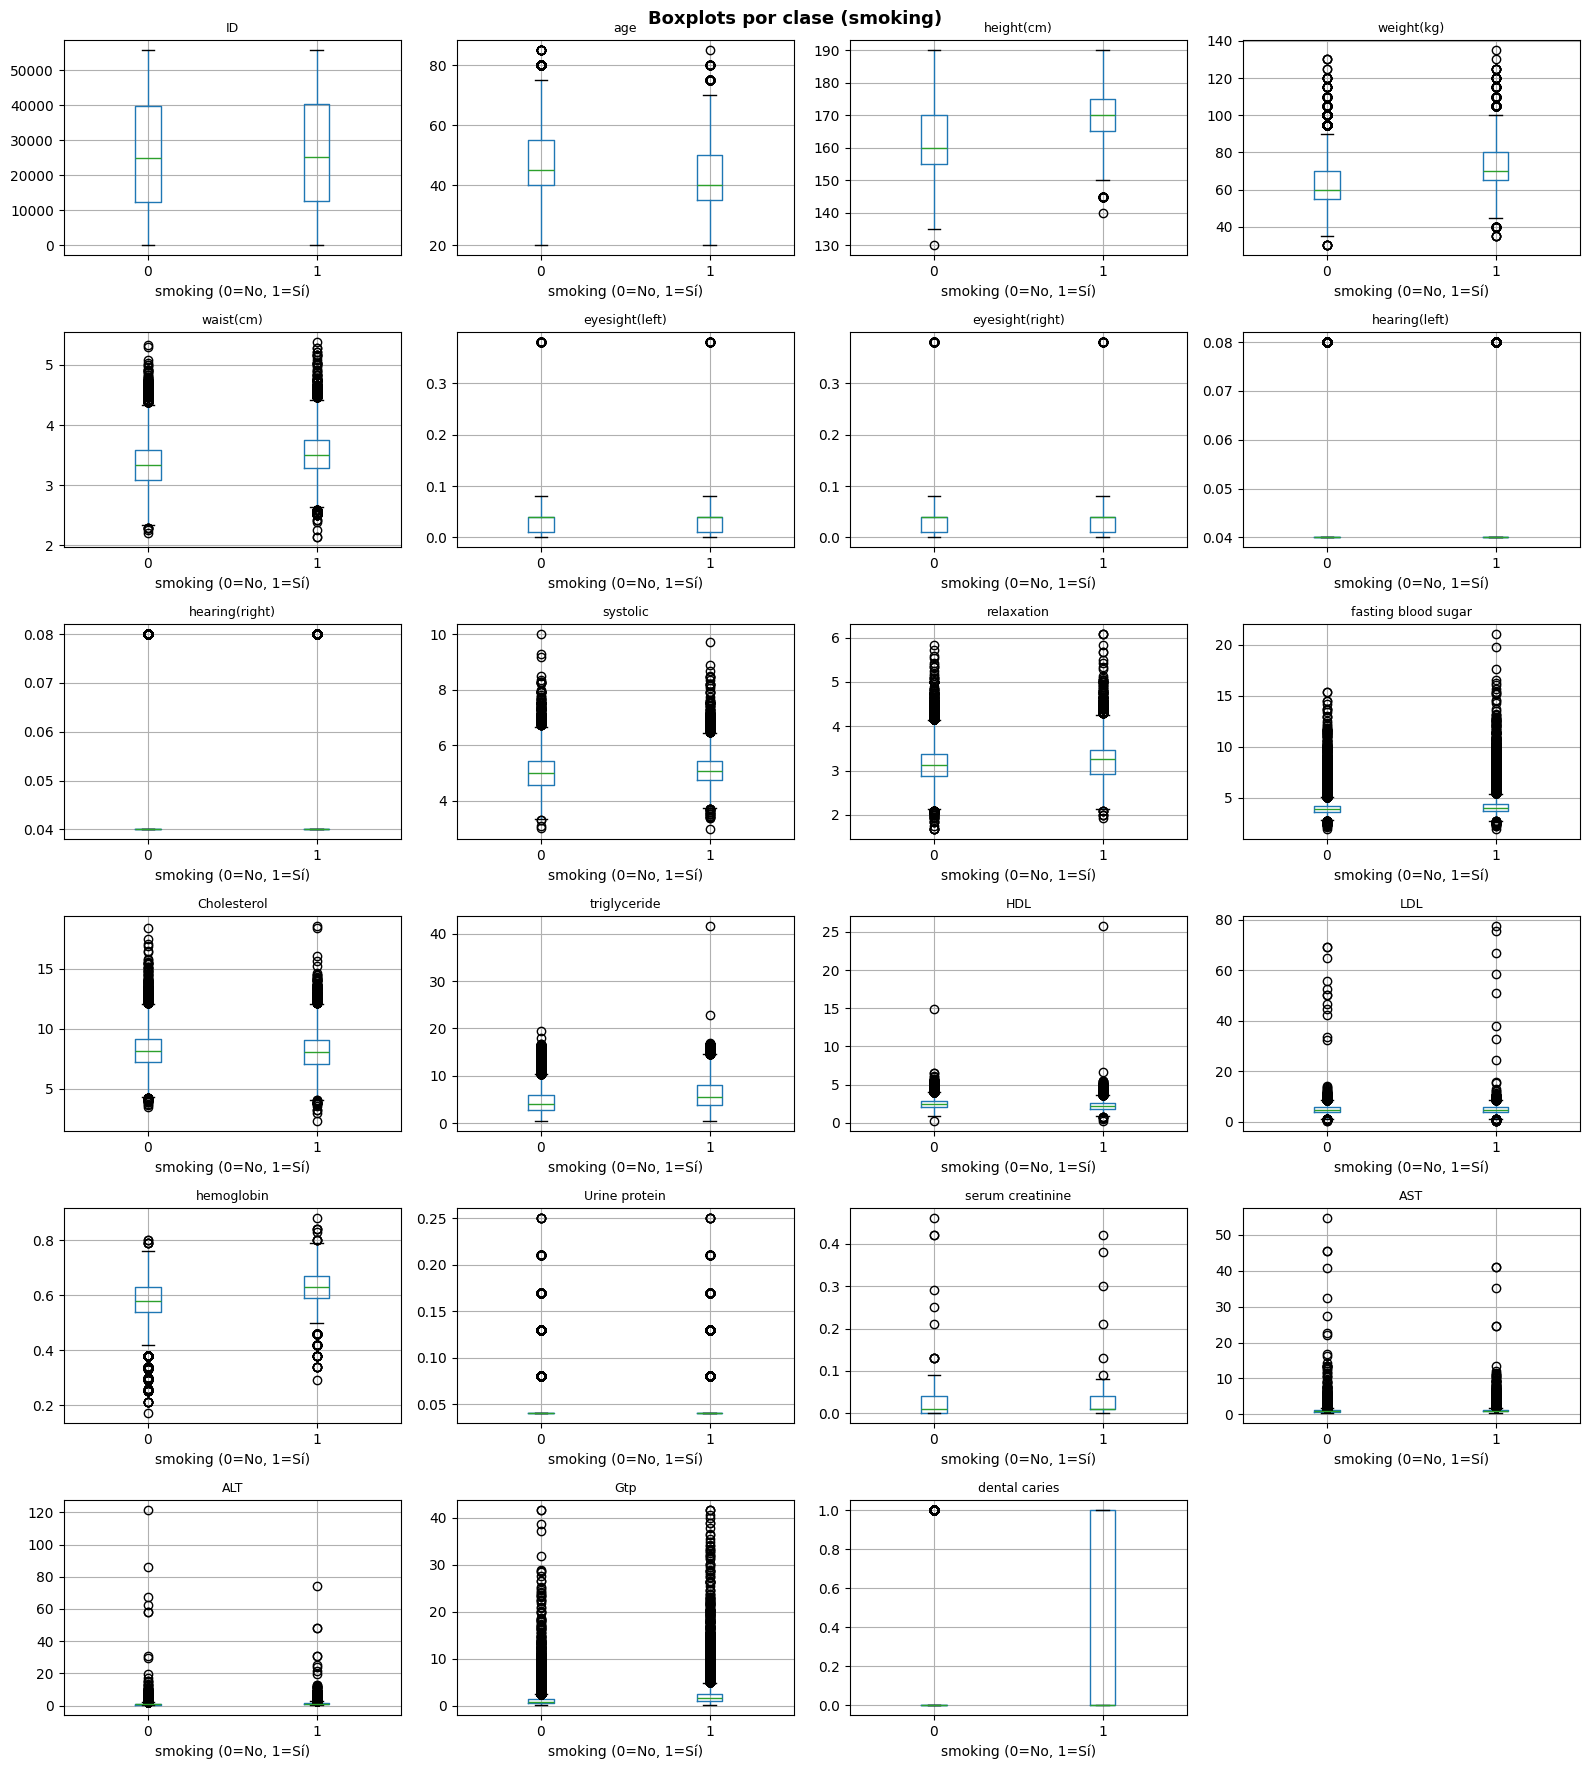

In [8]:

# ── Boxplots para detectar outliers ───────────────────────────────────────
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='smoking', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('smoking (0=No, 1=Sí)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por clase (smoking)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:

# ── Variables categóricas ─────────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    for col in cat_cols:
        print(f"\n{col}: {df[col].nunique()} valores únicos")
        print(df.groupby(col)['smoking'].agg(['mean','count']).rename(
            columns={'mean':'tasa_fumador','count':'n'}).sort_values('tasa_fumador', ascending=False))
else:
    print("No hay columnas categóricas.")



gender: 2 valores únicos
        tasa_fumador      n
gender                     
M           0.552165  31784
F           0.042765  18216

oral: 1 valores únicos
      tasa_fumador      n
oral                     
Y          0.36658  50000

tartar: 2 valores únicos
        tasa_fumador      n
tartar                     
Y           0.409730  27789
N           0.312593  22211


In [10]:

# ── Resumen estadístico por clase ─────────────────────────────────────────
print("Estadísticas descriptivas por clase (smoking):")
df.groupby('smoking')[num_cols].mean().T.round(2)


Estadísticas descriptivas por clase (smoking):


smoking,0,1
ID,26136.23,26542.05
age,45.70,41.59
height(cm),161.88,169.45
weight(kg),62.94,70.96
waist(cm),3.35,3.53
eyesight(left),0.03,0.03
eyesight(right),0.03,0.03
hearing(left),0.04,0.04
hearing(right),0.04,0.04
systolic,5.03,5.12
